In [ ]:
import pandas as pd


# 1. LOAD DATA
df = pd.read_csv("/content/model_list_20260616.csv")

# 2. FILTER LUNG DATA
lung_df_id = df[df["tissue"].str.lower() == "lung"]

# Reset index (optional)
lung_df = lung_df_id.reset_index(drop=True)

# 3. CHECK UNIQUE MODELS
unique_models = lung_df["model_id"].nunique()
print("✅ Unique lung models:", unique_models)

# Optional: see model IDs
print(lung_df["model_id"].unique())

# 4. SAVE FILE
lung_df.to_csv("/content/only_lung_model_final.csv", index=False)

print("✅ Lung dataset saved successfully!")
print("📊 Final shape:", lung_df.shape)

✅ Unique lung models: 317
['SIDM01554' 'SIDM01387' 'SIDM00990' 'SIDM00019' 'SIDM00046' 'SIDM01069'
 'SIDM00296' 'SIDM01163' 'SIDM01183' 'SIDM00307' 'SIDM00366' 'SIDM01986'
 'SIDM00486' 'SIDM01044' 'SIDM00133' 'SIDM00724' 'SIDM00719' 'SIDM00646'
 'SIDM00028' 'SIDM01596' 'SIDM01739' 'SIDM01545' 'SIDM00300' 'SIDM00236'
 'SIDM01226' 'SIDM00295' 'SIDM00103' 'SIDM00100' 'SIDM00099' 'SIDM00098'
 'SIDM00143' 'SIDM00104' 'SIDM00102' 'SIDM00101' 'SIDM00154' 'SIDM00114'
 'SIDM00137' 'SIDM00117' 'SIDM00116' 'SIDM00134' 'SIDM00223' 'SIDM00183'
 'SIDM00222' 'SIDM00245' 'SIDM00139' 'SIDM00138' 'SIDM00237' 'SIDM00311'
 'SIDM00306' 'SIDM00230' 'SIDM00341' 'SIDM00294' 'SIDM00292' 'SIDM00764'
 'SIDM00546' 'SIDM00297' 'SIDM00119' 'SIDM00310' 'SIDM00339' 'SIDM00357'
 'SIDM00356' 'SIDM00354' 'SIDM00365' 'SIDM00647' 'SIDM00642' 'SIDM00765'
 'SIDM00494' 'SIDM00513' 'SIDM00512' 'SIDM00510' 'SIDM00507' 'SIDM00508'
 'SIDM00506' 'SIDM00522' 'SIDM00523' 'SIDM00520' 'SIDM00519' 'SIDM00518'
 'SIDM00548' 'SIDM00547' 

In [ ]:
lung_df.columns

Index(['model_id', 'sample_id', 'patient_id', 'parent_id', 'model_name',
       'synonyms', 'tissue', 'cancer_type', 'cancer_type_ncit_id',
       'tissue_status', 'sample_site', 'cancer_type_detail', 'model_type',
       'growth_properties', 'model_treatment', 'sampling_day',
       'sampling_month', 'sampling_year', 'doi', 'pmed', 'msi_status',
       'ploidy_snp6', 'ploidy_wes', 'ploidy_wgs', 'mutational_burden',
       'model_comments', 'model_relations_comment', 'COSMIC_ID', 'BROAD_ID',
       'CCLE_ID', 'RRID', 'HCMI', 'suppliers', 'supplier', 'cat_number',
       'species', 'gender', 'ethnicity', 'age_at_sampling', 'cris_prediction',
       'cms_prediction', 'family_history_of_cancer', 'prior_same_malignancy',
       'prior_other_malignancy', 'smoking_status',
       'alcohol_exposure_intensity', 'alcohol_consumption_per_week',
       'history_diabetes', 'diabetes_treatment',
       'colorectal_cancer_risk_factors',
       'patient_history_of_gastrointestinal_disorder',
       '

In [ ]:
import csv

bad_rows = []

with open("/content/rnaseq_merged_rsem_tpm_20260323.csv") as f:
    reader = csv.reader(f)

    expected = len(next(reader))

    for i, row in enumerate(reader, start=2):
        if len(row) != expected:
            bad_rows.append((i, len(row)))

print("Number of bad rows:", len(bad_rows))
print(bad_rows[:20])

Number of bad rows: 1
[(41057, 2591)]


In [ ]:
import pandas as pd

# ========= STEP 1: LOAD FILES =========
rna_path = "/content/rnaseq_merged_rsem_tpm_20260323.csv"
lung_path = "/content/only_lung_model.csv"

rna = pd.read_csv(rna_path,
       engine="python",
       on_bad_lines="skip",
       low_memory=False)

lung_df = pd.read_csv(lung_path)

lung_ids = set(lung_df.iloc[:, 0].astype(str))


#  STEP 2: SET GENE INDEX
gene_col = rna.columns[0]
rna = rna.set_index(gene_col)


# STEP 3: REMOVE DUPLICATE GENES
# (duplicate rows based on gene names)
rna = rna[~rna.index.duplicated(keep='first')]

print("After removing duplicate genes:", rna.shape)


#  STEP 4: FILTER LUNG MODELS
lung_cols = [col for col in rna.columns if col in lung_ids]
rna_lung = rna[lung_cols]

print("After lung filtering:", rna_lung.shape)


# =STEP 5: TRANSPOSE
rna_lung = rna_lung.T


# ========= STEP 6: REMOVE DUPLICATE MODEL_IDs =========
rna_lung = rna_lung[~rna_lung.index.duplicated(keep='first')]


#  STEP 7: ADD MODEL_ID COLUMN
rna_lung.insert(0, "model_id", rna_lung.index)


#  STEP 8: FINAL DUPLICATE COLUMN CHECK
# Remove duplicate gene columns (if any)
rna_lung = rna_lung.loc[:, ~rna_lung.columns.duplicated()]


# STEP 9: SAVE
output_path = "/content/RNA_FULL_processeeD.csv"
rna_lung.to_csv(output_path, index=False)

print("✅ CLEAN FILE READY:", output_path)

After removing duplicate genes: (41147, 1900)
After lung filtering: (41147, 247)
✅ CLEAN FILE READY: /content/RNA_FULL_processeeD.csv


In [ ]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

rna = pd.read_csv("/content/RNA_FULL_processeeD.csv")

# Keep model_id separately
model_ids = rna["model_id"]

# Select ONLY numeric columns
genes = rna.select_dtypes(include=['int64', 'float64'])

print("Gene matrix shape:", genes.shape)

selector = VarianceThreshold(threshold=0.01)

genes_filtered = selector.fit_transform(genes)

selected_gene_names = genes.columns[selector.get_support()]

genes_filtered = pd.DataFrame(
    genes_filtered,
    columns=selected_gene_names,
    index=rna.index
)

rna_filtered = pd.concat(
    [model_ids, genes_filtered],
    axis=1
)

print(rna_filtered.shape)

Gene matrix shape: (247, 41145)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


(247, 27343)


In [ ]:
gene_variance = genes_filtered.var()

top_genes = gene_variance.sort_values(
    ascending=False
).head(5000).index

rna_filtered = pd.concat(
    [
        model_ids.reset_index(drop=True),
        genes_filtered[top_genes].reset_index(drop=True)
    ],
    axis=1
)

print(rna_filtered.shape)

(247, 5001)


In [ ]:
import pandas as pd


# 1. LOAD FILES
gdsc = pd.read_excel("/content/GDSC2_fitted_dose_response_27Oct23.xlsx")
lung_df = pd.read_csv("/content/only_lung_model (1).csv")

# 2. MATCH DATA TYPES
gdsc["SANGER_MODEL_ID"] = gdsc["SANGER_MODEL_ID"].astype(str)
lung_df["model_id"] = lung_df["model_id"].astype(str)

# 3. EXTRACT LUNG MODEL IDs
lung_ids = set(lung_df["model_id"])

# 4. FILTER GDSC
lung_gdsc = gdsc[gdsc["SANGER_MODEL_ID"].isin(lung_ids)]


# 5. SAVE FILE
lung_gdsc.to_csv("/content/LUNG_GDSC2.csv", index=False)

print("Original GDSC shape:", gdsc.shape)
print("Filtered GDSC shape:", lung_gdsc.shape)
print("Unique lung model IDs:", lung_gdsc["SANGER_MODEL_ID"].nunique())
print("File saved successfully!")

Original GDSC shape: (242036, 16)
Filtered GDSC shape: (46636, 16)
Unique lung model IDs: 190
File saved successfully!


In [ ]:
import pandas as pd

# Load files
rna = pd.read_csv("/content/RNA_FULL_processeeD.csv", low_memory=False)
gdsc = pd.read_csv("/content/LUNG_GDSC2.csv", low_memory=False)

# Convert IDs to string
rna["model_id"] = rna["model_id"].astype(str)
gdsc["SANGER_MODEL_ID"] = gdsc["SANGER_MODEL_ID"].astype(str)

# Find common models
common_models = sorted(set(rna["model_id"]).intersection(set(gdsc["SANGER_MODEL_ID"])))

# Results
print("Unique RNA models:", rna["model_id"].nunique())
print("Unique GDSC models:", gdsc["SANGER_MODEL_ID"].nunique())
print("Common unique models:", len(common_models))
print("\nCommon Model IDs:")
print(common_models)

Unique RNA models: 247
Unique GDSC models: 190
Common unique models: 171

Common Model IDs:
['SIDM00046', 'SIDM00047', 'SIDM00048', 'SIDM00116', 'SIDM00117', 'SIDM00119', 'SIDM00133', 'SIDM00134', 'SIDM00137', 'SIDM00138', 'SIDM00139', 'SIDM00143', 'SIDM00144', 'SIDM00183', 'SIDM00222', 'SIDM00223', 'SIDM00224', 'SIDM00230', 'SIDM00237', 'SIDM00245', 'SIDM00292', 'SIDM00293', 'SIDM00294', 'SIDM00296', 'SIDM00297', 'SIDM00300', 'SIDM00306', 'SIDM00320', 'SIDM00339', 'SIDM00341', 'SIDM00344', 'SIDM00345', 'SIDM00354', 'SIDM00355', 'SIDM00356', 'SIDM00365', 'SIDM00367', 'SIDM00368', 'SIDM00486', 'SIDM00493', 'SIDM00494', 'SIDM00506', 'SIDM00507', 'SIDM00508', 'SIDM00509', 'SIDM00510', 'SIDM00511', 'SIDM00512', 'SIDM00513', 'SIDM00521', 'SIDM00522', 'SIDM00523', 'SIDM00524', 'SIDM00547', 'SIDM00548', 'SIDM00598', 'SIDM00606', 'SIDM00640', 'SIDM00645', 'SIDM00646', 'SIDM00649', 'SIDM00651', 'SIDM00652', 'SIDM00653', 'SIDM00654', 'SIDM00658', 'SIDM00697', 'SIDM00698', 'SIDM00699', 'SIDM00700

In [ ]:
import pandas as pd

# Load GDSC
gdsc = pd.read_csv("/content/LUNG_GDSC2.csv", low_memory=False)

# Keep only required columns
gdsc = gdsc[
    [
        "SANGER_MODEL_ID",
        "DRUG_NAME",
        "PUTATIVE_TARGET",
        "PATHWAY_NAME",
        "LN_IC50",
        "AUC",
        "RMSE"
    ]
]

# Drugs present in all 171 models
drug_counts = gdsc.groupby("DRUG_NAME")["SANGER_MODEL_ID"].nunique()

complete_drugs = drug_counts[drug_counts == 171].index.tolist()

print("Number of complete drugs:", len(complete_drugs))
print(complete_drugs)

# Keep only those drugs
gdsc = gdsc[gdsc["DRUG_NAME"].isin(complete_drugs)]

print("Shape:", gdsc.shape)

Number of complete drugs: 33
['AGI-6780', 'AZ960', 'AZD5582', 'BMS-345541', 'CZC24832', 'Dinaciclib', 'Entinostat', 'Entospletinib', 'I-BET-762', 'IWP-2', 'Ibrutinib', 'KRAS (G12C) Inhibitor-12', 'LCL161', 'LY2109761', 'Leflunomide', 'ML323', 'MN-64', 'Mirin', 'Niraparib', 'OF-1', 'OTX015', 'PCI-34051', 'PFI3', 'PRIMA-1MET', 'PRT062607', 'Picolinici-acid', 'RVX-208', 'Ruxolitinib', 'Sabutoclax', 'VE-822', 'WZ4003', 'Wnt-C59', 'XAV939']
Shape: (5643, 7)


In [ ]:
gdsc["SANGER_MODEL_ID"] = (
    gdsc["SANGER_MODEL_ID"]
    .astype(str)
    .str.strip()
)

merged = pd.merge(
    gdsc,
    rna_filtered,
    left_on="SANGER_MODEL_ID",
    right_on="model_id",
    how="inner"
)

print(merged.shape)

merged.to_csv(
    "/content/Pharmacogenomics_Finale.csv",
    index=False
)

(5082, 5008)


In [ ]:
gdsc["SANGER_MODEL_ID"] = (
    gdsc["SANGER_MODEL_ID"]
    .astype(str)
    .str.strip()
)

merged = pd.merge(
    gdsc,
    rna_filtered,
    left_on="SANGER_MODEL_ID",
    right_on="model_id",
    how="inner"
)

print(merged.shape)

merged.to_csv(
    "/content/Pharmacogenomics_Finale.csv",
    index=False
)

(5082, 5008)


Dataset shape: (5082, 5008)
Numerical features: 5000
Categorical features: 3

Training samples: (4059, 5003)
Testing samples: (1023, 5003)
Training groups: 123
Testing groups: 31
Fitting 5 folds for each of 10 candidates, totalling 50 fits

RF BEST PARAMS:
{'select__k': 1000, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
RF BEST CV R2:
0.6119695035642893
Fitting 5 folds for each of 10 candidates, totalling 50 fits

XGB BEST PARAMS:
{'select__k': 1500, 'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__reg_alpha': 1, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.6}
XGB BEST CV R2:
0.6241186470288579

Winner: XGBoost

Best Development CV R2:
0.6241186470288579

FINAL UNTOUCHED TEST RESULT
Final Test R2: 0.6466042808736753

First 10 actual values:
[5.21063  5.000072 5.720759 

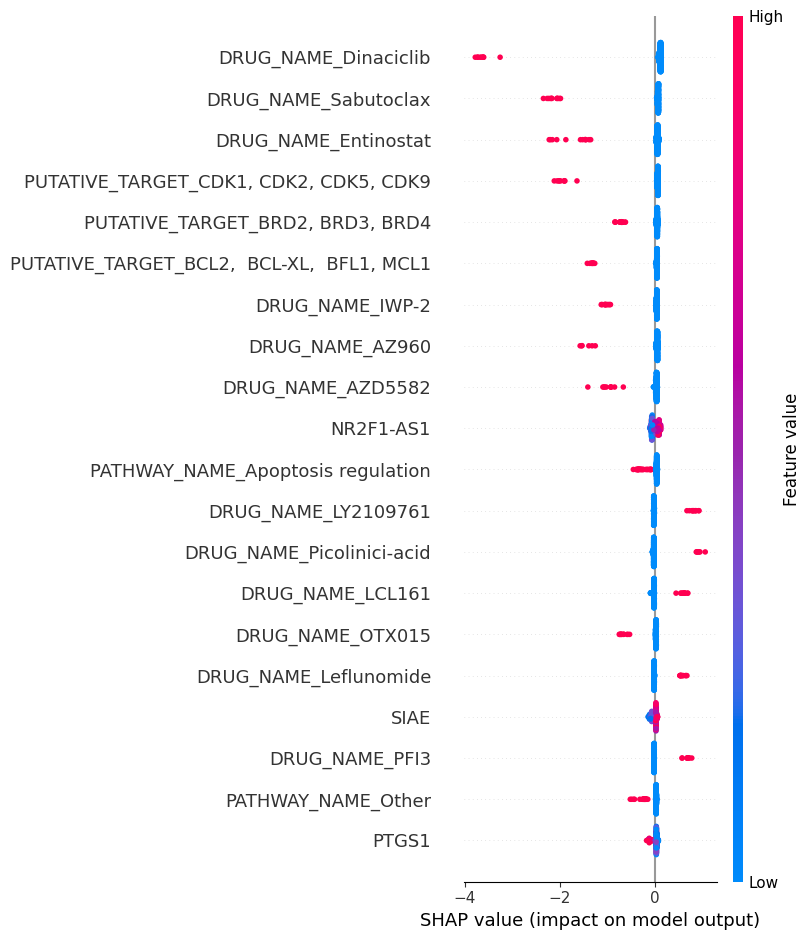

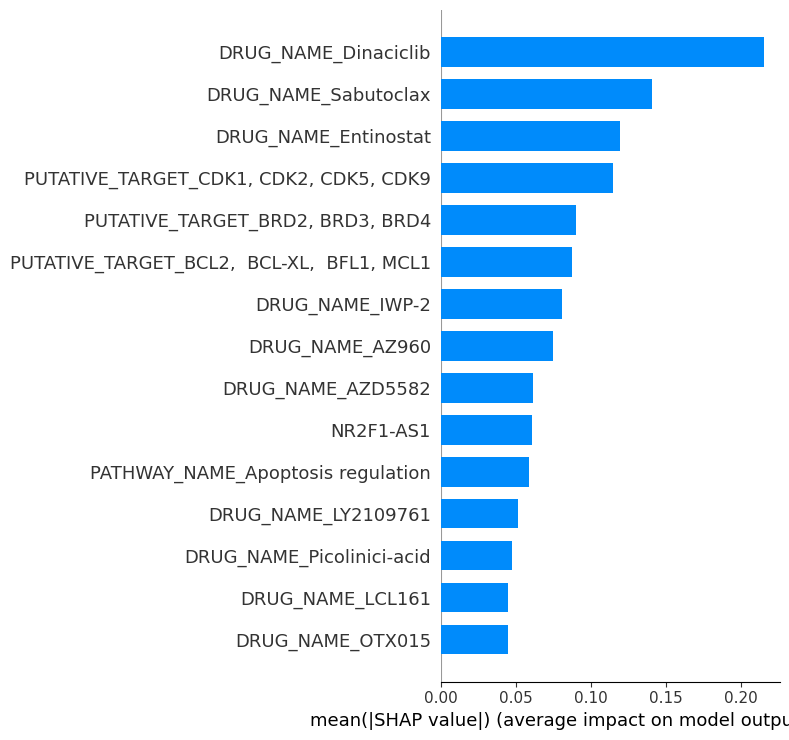

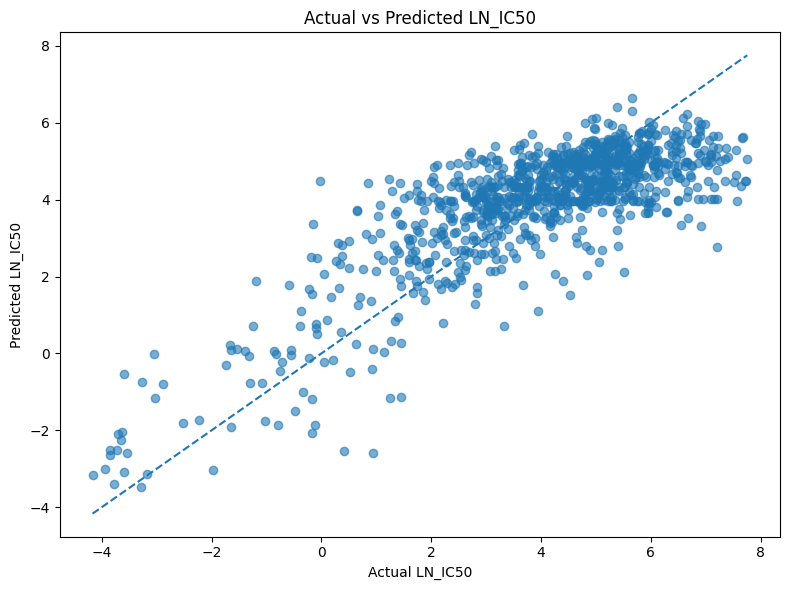

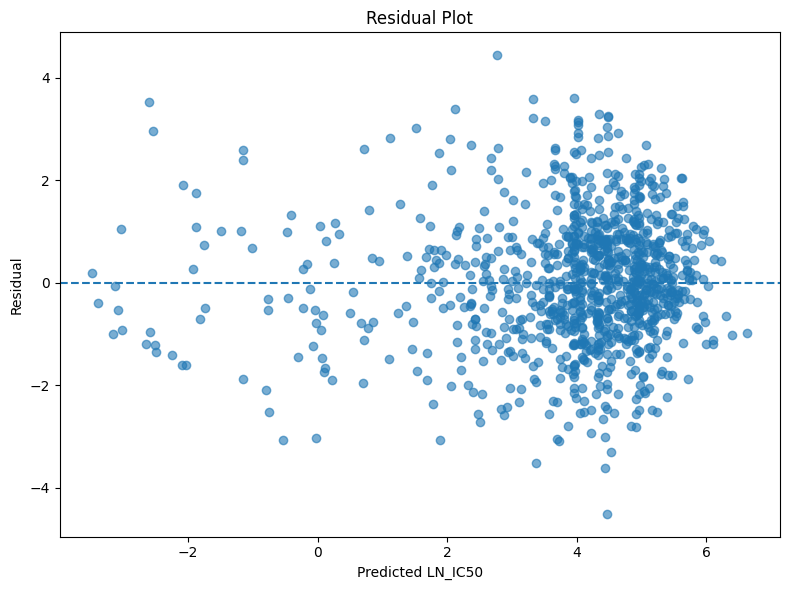

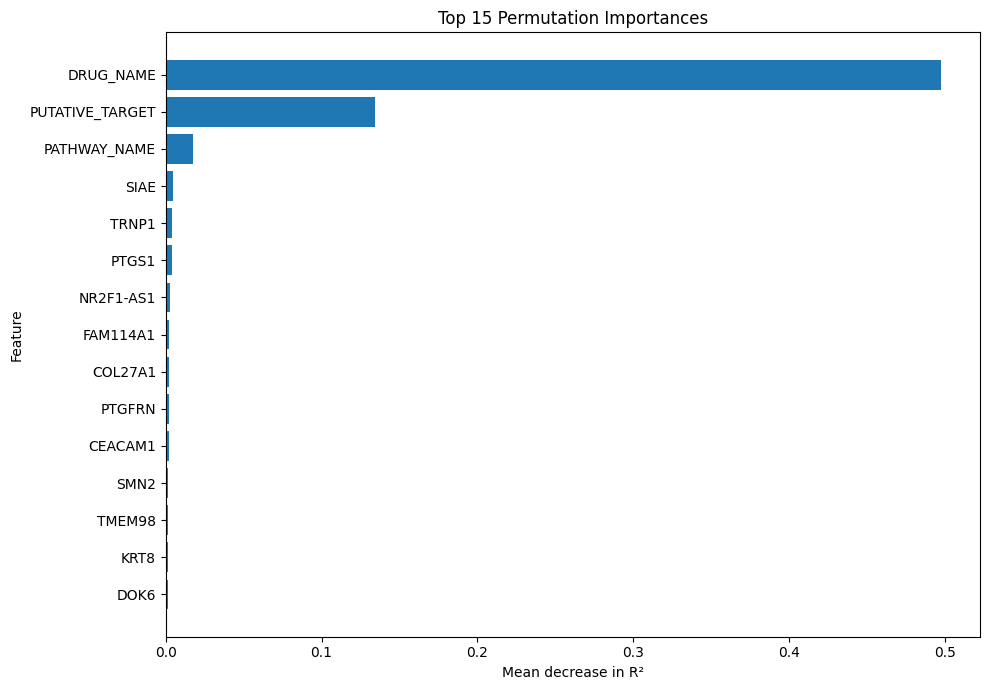

In [ ]:

# 1. IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.feature_selection import  SelectKBest, f_regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor



# 2. LOAD DATA

df = pd.read_csv(
    "/content/Pharmacogenomics_Finale.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Dataset shape:", df.shape)



# 3. TARGET

y = df["LN_IC50"]


# 4. FEATURES

X = df.drop(
    columns=[
        "LN_IC50",
        "model_id",
        "AUC",
         "SANGER_MODEL_ID",
        "RMSE"
    ],
    errors="ignore"
)

# 5. GROUPS

groups = df["SANGER_MODEL_ID"]


# 6. COLUMN TYPES

categorical_cols = [
    "DRUG_NAME",
    "PUTATIVE_TARGET",
    "PATHWAY_NAME"
]

numerical_cols = X.select_dtypes(
    include=np.number
).columns.tolist()


print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))


# 7. GROUPED TRAIN / TEST SPLIT

split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("\nTraining samples:", X_train.shape)
print("Testing samples:", X_test.shape)

print("Training groups:", groups_train.nunique())
print("Testing groups:", groups_test.nunique())


# 8. PREPROCESSING

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numerical_cols),
    ("cat", categorical_pipe, categorical_cols)
])



# 9. GROUP K-FOLD

cv = GroupKFold(n_splits=5)

# 10. RANDOM FOREST

rf_pipe = Pipeline([
    ("preprocess", preprocessor),


    ("select", SelectKBest(
        score_func=f_regression,
        k=1000
    )),

    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1
    ))
])


rf_params = {

    "select__k": [
        500,
        1000,
        1500

    ],

    "model__n_estimators": [
        100,
        200

    ],

    "model__max_depth": [
        10,
        20,
        None
    ],

    "model__min_samples_split": [
        2,
        5

    ],

    "model__min_samples_leaf": [
        1,
        2

    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.5
    ]
}


rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params,
    n_iter=10,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("\nRF BEST PARAMS:")
print(rf_search.best_params_)

print("RF BEST CV R2:")
print(rf_search.best_score_)



# 11. XGBOOST

xgb_pipe = Pipeline([
    ("preprocess", preprocessor),

    ("select", SelectKBest(
        score_func=f_regression,
        k=1000
    )),

    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1
    ))
])


xgb_params = {

    "select__k": [
        500,
        1000,
        1500

    ],

    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        3,
        5,
        7
    ],

    "model__learning_rate": [

        0.03,
        0.05,
        0.1
    ],

    "model__subsample": [

        0.8,
        1.0
    ],

    "model__colsample_bytree": [

        0.6,
        0.8

    ],

    "model__min_child_weight": [

        3,
        5

    ],

    "model__reg_alpha": [
        0,
        1

    ],

    "model__reg_lambda": [

        5,
        10

    ],

    "model__gamma": [
        0,
        0.1

    ]
}


xgb_search = RandomizedSearchCV(
    xgb_pipe,
    xgb_params,
    n_iter=10,
    scoring="r2",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("\nXGB BEST PARAMS:")
print(xgb_search.best_params_)

print("XGB BEST CV R2:")
print(xgb_search.best_score_)


# 12. SELECT WINNER

if rf_search.best_score_ > xgb_search.best_score_:

    best_model = rf_search.best_estimator_

    print("\nWinner: Random Forest")

else:

    best_model = xgb_search.best_estimator_

    print("\nWinner: XGBoost")


# 13. DEVELOPMENT CV RESULT

print("\nBest Development CV R2:")

print(
    max(
        rf_search.best_score_,
        xgb_search.best_score_
    )
)



# 14. FINAL TEST
# X_test was NEVER used during RandomizedSearchCV


test_r2 = best_model.score(
    X_test,
    y_test
)

print("\n======================================")
print("FINAL UNTOUCHED TEST RESULT")
print("======================================")

print("Final Test R2:", test_r2)


# 15. TEST PREDICTIONS

y_pred = best_model.predict(X_test)


print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])


# 16. PERMUTATION IMPORTANCE

X_sample = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

y_sample = y_test.loc[X_sample.index]


perm = permutation_importance(
    best_model,
    X_sample,
    y_sample,
    n_repeats=3,
    random_state=42,
    scoring="r2",
    n_jobs=1
)

print("\nTop 10 permutation importance values:")

order = np.argsort(
    perm.importances_mean
)[::-1]

print(
    perm.importances_mean[order[:10]]
)



# 17. SHAP

X_shap = X_test.sample(
    n=min(300, len(X_test)),
    random_state=42
)

X_transformed = best_model[:-1].transform(
    X_shap
)

# 18. SHAP FEATURE NAMES

feature_names = (
    best_model
    .named_steps["preprocess"]
    .get_feature_names_out()
)


feature_names = feature_names[
    best_model
    .named_steps["select"]
    .get_support()
]

feature_names = [
    x.replace("num__", "")
     .replace("cat__", "")
    for x in feature_names
]



# 19. SHAP

model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_transformed
)



# 20. SHAP SUMMARY PLOT

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    show=True
)

# 21. SHAP GLOBAL IMPORTANCE

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=True
)

# 22. ACTUAL VS PREDICTED

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title("Actual vs Predicted LN_IC50")

plt.tight_layout()
plt.show()

# RESIDUAL PLOT

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted LN_IC50")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()


# PERMUTATION IMPORTANCE

importance_values = perm.importances_mean

feature_names_perm = X_sample.columns

order = np.argsort(
    importance_values
)[::-1]

top_n = 15
top_indices = order[:top_n]

plt.figure(figsize=(10, 7))

plt.barh(
    range(top_n),
    importance_values[top_indices]
)

plt.yticks(
    range(top_n),
    feature_names_perm[top_indices]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean decrease in R²")
plt.ylabel("Feature")
plt.title("Top 15 Permutation Importances")

plt.tight_layout()
plt.show()
